In [1796]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [1797]:
data_folder = "/gdrive/MyDrive/data/"

In [1798]:
!ls /gdrive/MyDrive/data

bible_fra.txt	   glove.6B.100d.txt  Synthetic_Financial_datasets_log.csv.zip
births.csv	   glove.6B.200d.txt  tweets.csv
births_github.csv  glove.6B.300d.txt  WASTE_COURT.zip
decades.csv	   glove.6B.50d.txt   WASTE.zip
exemple.txt	   station.csv


# Import Data

In [1799]:
import pandas as pd

In [1800]:
df = pd.read_csv(data_folder + 'station.csv')

In [1801]:
len(df)

53

In [1802]:
# df = df.iloc[:-1]

In [1803]:
# len(df)

In [1804]:
df.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,D-J-F,M-A-M,J-J-A,S-O-N,metANN
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,1999.000000,5.131509,5.556415,7.510377,9.346604,12.569811,34.103585,17.636604,17.728868,34.016038,30.818868,26.985094,24.705472,5.539434,9.808868,16.967170,30.606604,11.076226
std,15.443445,1.978247,2.012753,1.324834,1.251132,1.190510,135.218720,1.214431,1.228015,135.231366,135.681299,136.216820,136.539315,1.242591,0.928306,0.952283,135.706328,0.755259
min,1973.000000,-1.010000,-1.060000,4.570000,6.510000,9.790000,13.210000,15.480000,15.140000,12.840000,8.370000,4.270000,1.670000,2.990000,8.100000,14.780000,9.350000,9.550000
25%,1986.000000,4.280000,4.170000,6.430000,8.640000,11.560000,14.420000,16.520000,16.940000,14.600000,11.160000,7.590000,4.870000,4.680000,9.070000,16.450000,11.360000,10.540000
50%,1999.000000,5.270000,5.630000,7.630000,9.150000,12.770000,15.560000,17.790000,17.700000,15.360000,12.070000,8.260000,6.060000,5.760000,10.020000,17.020000,11.940000,10.980000
75%,2012.000000,6.750000,7.140000,8.540000,10.160000,13.180000,16.260000,18.560000,18.430000,16.270000,13.190000,9.160000,7.190000,6.340000,10.510000,17.510000,12.460000,11.550000
max,2025.000000,7.960000,9.500000,10.080000,12.140000,14.660000,999.900000,19.990000,20.350000,999.900000,999.900000,999.900000,999.900000,7.750000,11.420000,18.880000,999.900000,12.700000


In [1805]:
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,D-J-F,M-A-M,J-J-A,S-O-N,metANN
0,1973,4.12,4.20,5.97,7.89,12.18,14.99,16.30,18.10,15.18,11.08,7.29,5.64,4.36,8.68,16.46,11.18,10.17
1,1974,7.07,6.10,6.74,9.15,11.00,14.33,15.84,16.61,13.35,8.37,8.42,8.64,6.27,8.96,15.59,10.05,10.22
2,1975,7.96,5.72,5.69,8.69,10.39,14.42,17.47,19.05,15.15,10.51,7.10,3.52,7.44,8.26,16.98,10.92,10.90
3,1976,5.75,4.92,6.00,8.03,13.18,17.40,19.10,18.09,15.18,12.07,7.59,3.49,4.73,9.07,18.20,11.61,10.90
4,1977,4.15,7.39,8.24,7.94,11.23,13.21,16.22,15.55,13.40,12.72,7.94,7.43,5.01,9.14,14.99,11.35,10.12


In [1806]:
df.tail()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,D-J-F,M-A-M,J-J-A,S-O-N,metANN
48,2021,5.09,6.44,7.64,7.29,11.64,16.74,18.09,17.19,17.29,12.79,8.24,7.54,6.14,8.86,17.34,12.77,11.28
49,2022,5.69,7.54,9.19,9.84,14.19,16.94,19.69,19.94,16.29,15.09,10.44,5.00,6.92,11.07,18.86,13.94,12.70
50,2023,6.75,6.90,9.35,10.05,13.20,18.00,18.25,18.40,19.15,14.65,9.75,8.65,6.22,10.87,18.22,14.52,12.45
51,2024,5.10,9.50,9.30,10.90,14.05,15.25,18.25,19.50,15.40,13.25,9.00,7.40,7.75,11.42,17.67,12.55,12.35
52,2025,4.55,5.80,8.35,11.75,13.95,18.30,18.95,19.10,999.90,999.90,999.90,999.90,5.92,11.35,18.78,999.90,12.31


# Créer la série temporelle

In [1807]:
temps = df.loc[:, "JAN" : "DEC"]
temps

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,4.12,4.20,5.97,7.89,12.18,14.99,16.30,18.10,15.18,11.08,7.29,5.64
1,7.07,6.10,6.74,9.15,11.00,14.33,15.84,16.61,13.35,8.37,8.42,8.64
2,7.96,5.72,5.69,8.69,10.39,14.42,17.47,19.05,15.15,10.51,7.10,3.52
3,5.75,4.92,6.00,8.03,13.18,17.40,19.10,18.09,15.18,12.07,7.59,3.49
4,4.15,7.39,8.24,7.94,11.23,13.21,16.22,15.55,13.40,12.72,7.94,7.43
5,4.28,3.71,7.59,7.82,11.56,13.62,15.57,15.14,14.60,12.73,9.16,5.18
6,0.46,3.34,6.20,8.35,10.77,13.79,16.52,15.49,14.38,11.95,8.17,7.04
7,1.98,7.01,5.85,8.60,11.17,14.42,15.48,17.11,15.46,10.31,6.53,5.13
8,5.55,3.30,9.56,8.36,11.76,13.80,16.12,16.89,15.03,10.49,8.33,4.68
9,4.54,5.63,6.06,8.68,12.99,16.89,17.22,16.88,16.33,11.10,8.63,5.11


In [1808]:
series = []

for i , row in temps.iterrows():
  series += list(row)

In [1809]:
print(series)

[4.12, 4.2, 5.97, 7.89, 12.18, 14.99, 16.3, 18.1, 15.18, 11.08, 7.29, 5.64, 7.07, 6.1, 6.74, 9.15, 11.0, 14.33, 15.84, 16.61, 13.35, 8.37, 8.42, 8.64, 7.96, 5.72, 5.69, 8.69, 10.39, 14.42, 17.47, 19.05, 15.15, 10.51, 7.1, 3.52, 5.75, 4.92, 6.0, 8.03, 13.18, 17.4, 19.1, 18.09, 15.18, 12.07, 7.59, 3.49, 4.15, 7.39, 8.24, 7.94, 11.23, 13.21, 16.22, 15.55, 13.4, 12.72, 7.94, 7.43, 4.28, 3.71, 7.59, 7.82, 11.56, 13.62, 15.57, 15.14, 14.6, 12.73, 9.16, 5.18, 0.46, 3.34, 6.2, 8.35, 10.77, 13.79, 16.52, 15.49, 14.38, 11.95, 8.17, 7.04, 1.98, 7.01, 5.85, 8.6, 11.17, 14.42, 15.48, 17.11, 15.46, 10.31, 6.53, 5.13, 5.55, 3.3, 9.56, 8.36, 11.76, 13.8, 16.12, 16.89, 15.03, 10.49, 8.33, 4.68, 4.54, 5.63, 6.06, 8.68, 12.99, 16.89, 17.22, 16.88, 16.33, 11.1, 8.63, 5.11, 7.11, 1.82, 6.55, 7.95, 11.22, 15.09, 19.99, 17.7, 16.04, 11.64, 8.14, 5.35, 5.81, 4.98, 5.89, 9.18, 9.79, 14.88, 18.07, 18.55, 15.15, 11.94, 9.61, 5.38, 0.65, 2.99, 5.58, 9.18, 11.55, 14.14, 17.51, 15.78, 15.7, 11.32, 5.02, 6.84, 5.37,

In [1810]:
53*12

636

In [1811]:
len(series)

636

In [1812]:
series = series[:-4]

In [1813]:
len(series)

632

In [1814]:
import numpy as np

In [1815]:
series = np.array(series)

In [1816]:
series

array([ 4.120e+00,  4.200e+00,  5.970e+00,  7.890e+00,  1.218e+01,
        1.499e+01,  1.630e+01,  1.810e+01,  1.518e+01,  1.108e+01,
        7.290e+00,  5.640e+00,  7.070e+00,  6.100e+00,  6.740e+00,
        9.150e+00,  1.100e+01,  1.433e+01,  1.584e+01,  1.661e+01,
        1.335e+01,  8.370e+00,  8.420e+00,  8.640e+00,  7.960e+00,
        5.720e+00,  5.690e+00,  8.690e+00,  1.039e+01,  1.442e+01,
        1.747e+01,  1.905e+01,  1.515e+01,  1.051e+01,  7.100e+00,
        3.520e+00,  5.750e+00,  4.920e+00,  6.000e+00,  8.030e+00,
        1.318e+01,  1.740e+01,  1.910e+01,  1.809e+01,  1.518e+01,
        1.207e+01,  7.590e+00,  3.490e+00,  4.150e+00,  7.390e+00,
        8.240e+00,  7.940e+00,  1.123e+01,  1.321e+01,  1.622e+01,
        1.555e+01,  1.340e+01,  1.272e+01,  7.940e+00,  7.430e+00,
        4.280e+00,  3.710e+00,  7.590e+00,  7.820e+00,  1.156e+01,
        1.362e+01,  1.557e+01,  1.514e+01,  1.460e+01,  1.273e+01,
        9.160e+00,  5.180e+00,  4.600e-01,  3.340e+00,  6.200e

In [1817]:
series.shape

(632,)

# Data Visualization

In [1818]:
import matplotlib.pyplot as plt

In [1819]:
time = np.arange(len(series))

In [1820]:
time

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

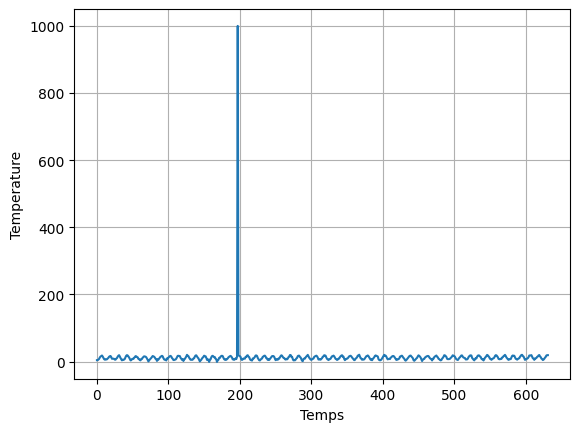

In [1821]:
plt.plot(time, series)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid()
plt.show()

In [1822]:
np.argmax(series)

np.int64(197)

In [1823]:
series[197]

np.float64(999.9)

In [1824]:
extraits = series[196:199]
extraits

array([ 14.16, 999.9 ,  18.63])

In [1825]:
extraits = np.delete(extraits, 1)
extraits

array([14.16, 18.63])

In [1826]:
np.mean(extraits)

np.float64(16.395)

In [1827]:
series.max()

np.float64(999.9)

In [1828]:
series[197] = np.mean(extraits)

In [1829]:
series[196:199]

array([14.16 , 16.395, 18.63 ])

In [1830]:
series.max()

np.float64(20.35)

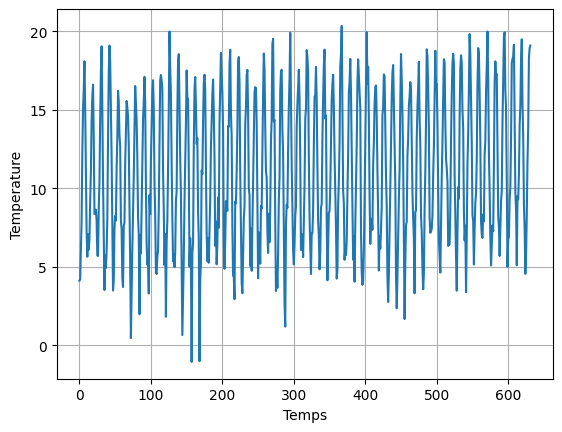

In [1831]:
plt.plot(time, series)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid()
plt.show()

# Baseline (Modèle le + simple possible)

In [1832]:
len(series)*.80

505.6

In [1833]:
split = 532 # pour être env. 80% mais avoir pile 100 vals pour test

In [1834]:
# train_test_split

time_train = time[:split]
x_train = series[:split]

time_test = time[split:]
x_test = series[split:]

In [1835]:
years = df['YEAR'].tolist()
print (len(years), years)

53 [1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [1836]:
split/12

44.333333333333336

In [1837]:
years[44] # 1973-2016 train, 2016-2025 test

2017

## Approche naïve

In [1838]:
pred_naive = series[split-1:-1]
len(pred_naive)

100

In [1839]:
pred_naive.shape

(100,)

In [1840]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [1841]:
mean_absolute_error(x_test, pred_naive)

2.4012999999999995

In [1842]:
mean_squared_error(x_test, pred_naive)

8.147757

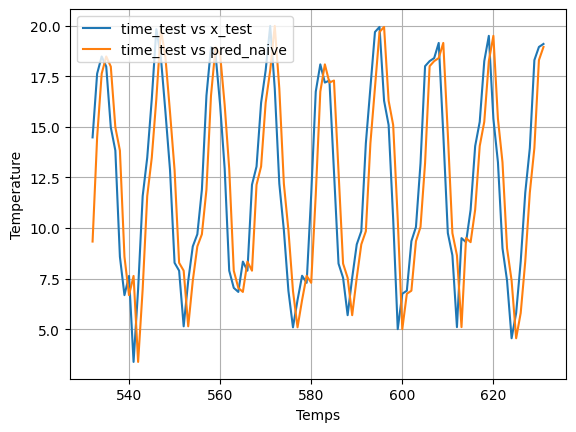

In [1843]:
plt.plot(time_test, x_test, label='time_test vs x_test')
plt.plot(time_test, pred_naive, label='time_test vs pred_naive') # courbe orange
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid()
plt.show()

 # Deep Learning

## Creer un windowed dataset

In [1844]:
import tensorflow as tf

In [1845]:
dataset = tf.data.Dataset.range(10)

In [1846]:
dataset

<_RangeDataset element_spec=TensorSpec(shape=(), dtype=tf.int64, name=None)>

In [1847]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))

for window in dataset:
  print(window.numpy())

[0 1 2 3 4]
[1 2 3 4 5]
[2 3 4 5 6]
[3 4 5 6 7]
[4 5 6 7 8]
[5 6 7 8 9]


In [1848]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))

In [1849]:
for x, y in dataset:
  print(x.numpy(), y.numpy())

[0 1 2 3] 4
[1 2 3 4] 5
[2 3 4 5] 6
[3 4 5 6] 7
[4 5 6 7] 8
[5 6 7 8] 9


In [1850]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
dataset = dataset.shuffle(buffer_size=10)

dataset = dataset.batch(2).prefetch(1)


In [1851]:
for x, y in dataset:
  print(x.numpy(), y.numpy())

[[3 4 5 6]
 [0 1 2 3]] [7 4]
[[4 5 6 7]
 [1 2 3 4]] [8 5]
[[5 6 7 8]
 [2 3 4 5]] [9 6]


In [1852]:
dataset = tf.data.Dataset.from_tensor_slices(series)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
dataset = dataset.shuffle(buffer_size=len(series))

dataset = dataset.batch(32).prefetch(1)

In [1853]:
def windowed_dataset(series, window_size, batch_size):
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size+1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size+1))
  dataset = dataset.map(lambda window: (window[:-1], window[-1]))
  # dataset = dataset.shuffle(buffer_size=len(series))

  dataset = dataset.batch(batch_size).prefetch(1)

  return dataset

In [1854]:
window_size = 24
batch_size = 32
dataset = windowed_dataset(x_train, window_size, batch_size)
test_dataset = windowed_dataset(x_test, window_size, batch_size)

# Réseaux de Neurones

In [1855]:
for feature, label in test_dataset.take(1):
  print(feature.shape)
  print(label.shape)

(32, 24)
(32,)


In [1856]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(10, input_shape=[24], activation='relu'),
    tf.keras.layers.Dense(10,  activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [1857]:
model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [1858]:
model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))


In [1859]:
model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 103.8850 - val_loss: 111.0141
Epoch 2/100
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 92.6862

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 81.7103 - val_loss: 78.1989
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 58.4558 - val_loss: 55.5335
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 43.3928 - val_loss: 42.2041
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 34.4302 - val_loss: 33.7137
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28.6873 - val_loss: 27.9090
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.6710 - val_loss: 23.6378
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.6101 - val_loss: 20.3691
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19.1529 - val_loss: 17.7727
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17.1169 - val_loss: 15.6267
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.4057 - val_loss: 13.8737
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.9479 - val_loss: 12.3846
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

# Prediction avec reseaux de neurones

In [1860]:
x_test

array([14.48, 17.63, 18.48, 17.98, 14.98, 13.83,  8.58,  6.68,  7.63,
        3.38,  6.98, 11.58, 13.48, 16.38, 19.83, 18.43, 15.73, 12.88,
        8.28,  7.89,  5.14,  7.39,  9.09,  9.69, 11.89, 16.54, 18.94,
       18.59, 16.09, 12.94,  7.89,  7.04,  6.84,  8.34,  7.89, 12.14,
       13.04, 16.19, 17.79, 19.99, 16.89, 12.19,  9.89,  6.89,  5.09,
        6.44,  7.64,  7.29, 11.64, 16.74, 18.09, 17.19, 17.29, 12.79,
        8.24,  7.54,  5.69,  7.54,  9.19,  9.84, 14.19, 16.94, 19.69,
       19.94, 16.29, 15.09, 10.44,  5.  ,  6.75,  6.9 ,  9.35, 10.05,
       13.2 , 18.  , 18.25, 18.4 , 19.15, 14.65,  9.75,  8.65,  5.1 ,
        9.5 ,  9.3 , 10.9 , 14.05, 15.25, 18.25, 19.5 , 15.4 , 13.25,
        9.  ,  7.4 ,  4.55,  5.8 ,  8.35, 11.75, 13.95, 18.3 , 18.95,
       19.1 ])

In [1861]:
series[split-24:split].shape

(24,)

In [1862]:
r = model.predict(series[split-24:split].reshape(1, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [1863]:
r.item()

14.672767639160156

In [1864]:
forecast = []

for time in range(split-24, split+100-24):

  series_to_predict = series[time: time+24].reshape(1, -1)
  r = model.predict(series_to_predict)
  forecast.append(r.item())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

In [1865]:
print(forecast)

[14.672767639160156, 14.273768424987793, 16.642927169799805, 18.11390495300293, 16.624353408813477, 13.61817455291748, 9.955504417419434, 6.220074653625488, 4.976819038391113, 6.747744083404541, 9.367706298828125, 9.199319839477539, 14.079244613647461, 15.984972953796387, 17.395143508911133, 19.823225021362305, 16.461275100708008, 12.642830848693848, 8.109843254089355, 5.345498085021973, 4.655198097229004, 6.255352973937988, 9.136491775512695, 11.516769409179688, 12.951948165893555, 15.432318687438965, 18.14228057861328, 17.096872329711914, 17.052488327026367, 14.614513397216797, 8.663658142089844, 5.503091812133789, 4.966785430908203, 5.688591003417969, 8.438298225402832, 11.236820220947266, 14.193071365356445, 15.489989280700684, 17.17400550842285, 17.74192237854004, 17.73278045654297, 13.740304946899414, 9.728793144226074, 5.841606140136719, 5.560808181762695, 6.489687919616699, 9.131969451904297, 11.519918441772461, 13.681831359863281, 14.81434154510498, 17.437095642089844, 17.9775

In [1866]:
forecast = np.array(forecast)

mae :  1.2323387718200685
mse :  2.3248642061804983


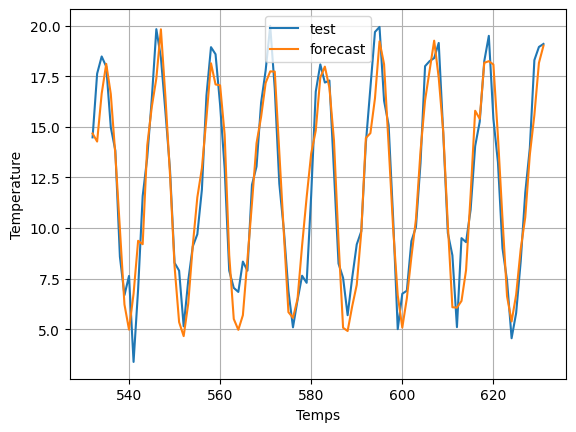

In [1883]:
print('mae : ', mean_absolute_error(x_test, forecast))
print('mse : ', mean_squared_error(x_test, forecast))
plt.plot(time_test, x_test, label = 'test')
plt.plot(time_test, forecast, label = 'forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

# Réseaux convolutionnels CNN

In [1868]:
series.shape

(632,)

In [1869]:
series.reshape(-1, 1).shape

(632, 1)

In [1870]:
def windowed_dataset(series, window_size, batch_size):
  series = series.reshape(-1, 1)
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size+1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size+1))
  dataset = dataset.map(lambda window: (window[:-1], window[-1]))
  # dataset = dataset.shuffle(buffer_size=len(series))

  dataset = dataset.batch(batch_size).prefetch(1)

  return dataset

In [1871]:
dataset = windowed_dataset(x_train, window_size, batch_size)
test_dataset = windowed_dataset(x_test, window_size, batch_size)

In [1872]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding='causal', input_shape=[None, 1],
                           activation='relu'),
    tf.keras.layers.Dense(28, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [1873]:
model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, None, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, None, 28)       │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, None, 10)       │           290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, None, 1)        │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,425 (17.29 KB)

 Trainable params: 4,425 (17.29 KB)

 Non-trainable params: 0 (0.00 B)

In [1874]:
model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 114.2361 - val_loss: 144.1853
Epoch 2/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 109.2222 - val_loss: 135.7654
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 102.9759 - val_loss: 127.3378
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 96.7682 - val_loss: 118.8505
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 90.2528 - val_loss: 107.7565
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 81.7339 - val_loss: 94.7864
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 72.6452 - val_loss: 83.2132
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 64.8170 - val_loss: 73.6638
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 58.4597 - val_loss: 65.8772
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 53.3423 - val_loss: 59.5529
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 49.3137 - val_loss: 54.5742
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 46.2682 - val_loss: 50.7917
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━

In [1875]:
def predict_dataset(model, series, window_size):

  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size))

  # dataset = dataset.shuffle(buffer_size=len(series))

  dataset = dataset.batch(32).prefetch(1)
  forecast = model.predict(dataset)

  return forecast

In [1876]:
x_test

array([14.48, 17.63, 18.48, 17.98, 14.98, 13.83,  8.58,  6.68,  7.63,
        3.38,  6.98, 11.58, 13.48, 16.38, 19.83, 18.43, 15.73, 12.88,
        8.28,  7.89,  5.14,  7.39,  9.09,  9.69, 11.89, 16.54, 18.94,
       18.59, 16.09, 12.94,  7.89,  7.04,  6.84,  8.34,  7.89, 12.14,
       13.04, 16.19, 17.79, 19.99, 16.89, 12.19,  9.89,  6.89,  5.09,
        6.44,  7.64,  7.29, 11.64, 16.74, 18.09, 17.19, 17.29, 12.79,
        8.24,  7.54,  5.69,  7.54,  9.19,  9.84, 14.19, 16.94, 19.69,
       19.94, 16.29, 15.09, 10.44,  5.  ,  6.75,  6.9 ,  9.35, 10.05,
       13.2 , 18.  , 18.25, 18.4 , 19.15, 14.65,  9.75,  8.65,  5.1 ,
        9.5 ,  9.3 , 10.9 , 14.05, 15.25, 18.25, 19.5 , 15.4 , 13.25,
        9.  ,  7.4 ,  4.55,  5.8 ,  8.35, 11.75, 13.95, 18.3 , 18.95,
       19.1 ])

In [1877]:
series[505-24:-1].shape

(150,)

In [1878]:
cnn_forecast = predict_dataset(model, series[505-24:-1], window_size)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [1879]:
cnn_forecast.shape

(127, 24, 1)

In [1880]:
results = cnn_forecast[:, -1, 0]

In [1881]:
results

array([ 6.7182555,  4.9981365,  6.0711045,  7.684118 ,  9.708938 ,
       12.024307 , 13.969838 , 14.7027   , 13.850315 , 12.647806 ,
       10.745413 ,  9.51045  ,  7.7837973,  7.127744 ,  5.606375 ,
        6.8345866,  9.425174 , 11.780553 , 13.896795 , 15.009894 ,
       15.23613  , 12.859491 , 11.043718 ,  7.178159 ,  5.147317 ,
        5.732385 ,  7.0954075,  7.651039 , 10.965935 , 12.911692 ,
       14.578767 , 15.148669 , 14.219636 , 13.372021 , 10.296459 ,
        8.7441   ,  6.930448 ,  4.8103905,  6.2093654,  7.8811607,
        9.975013 , 12.538865 , 15.00333  , 15.221486 , 15.044597 ,
       13.28187  , 10.40413  ,  8.766355 ,  5.978729 ,  6.538772 ,
        6.844284 ,  7.728847 ,  9.331033 , 12.152831 , 14.2555485,
       15.214482 , 14.852933 , 13.396491 , 10.425143 ,  8.456503 ,
        6.3444176,  6.8067565,  6.6291633,  9.221565 ,  9.945212 ,
       12.534351 , 13.792662 , 15.78906  , 14.925748 , 13.75664  ,
       11.347419 ,  8.279494 ,  6.502385 ,  5.7571898,  5.9519

In [1882]:
print('mae : ', mean_absolute_error(x_test, results))
print('mse : ', mean_squared_error(x_test, results))
plt.plot(time_test, x_test)
plt.plot(time_test, results)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [100, 127]

# Reseaux de Neurones Récurrents RNN

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.SimpleRNN(100, input_shape=[None, 1], return_sequences=True),
    tf.keras.layers.SimpleRNN(100),
    tf.keras.layers.Dense(1)
])

In [ ]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

In [ ]:
rnn_forecast = predict_dataset(model, series[505-24:-1], window_size)

In [ ]:
rnn_forecast.shape

In [ ]:
rnn_forecast = rnn_forecast[:, 0]

In [ ]:
rnn_forecast.shape

In [ ]:
x_test.shape

In [ ]:
print('mae : ', mean_absolute_error(x_test, rnn_forecast))
print('mse : ', mean_squared_error(x_test, rnn_forecast))
plt.plot(time_test, x_test)
plt.plot(time_test, rnn_forecast)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

# RNN Normalized

In [ ]:
x_train_scaled = (x_train - x_train.mean()) / x_train.std()
x_test_scaled = (x_test - x_train.mean()) / x_train.std()

In [ ]:
dataset = windowed_dataset(x_train_scaled, window_size, batch_size)
test_dataset = windowed_dataset(x_test_scaled, window_size, batch_size)

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.SimpleRNN(100, input_shape=[None, 1], return_sequences=True),
    tf.keras.layers.SimpleRNN(100),
    tf.keras.layers.Dense(1)
])

In [ ]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

In [ ]:
series_scaled = (series - series.mean()) / series.std()

In [ ]:
rnn_forecast = predict_dataset(model, series_scaled[505-24:-1], window_size)[:, 0]

In [ ]:
print('mae : ', mean_absolute_error(x_test_scaled, rnn_forecast))
print('mse : ', mean_squared_error(x_test_scaled, rnn_forecast))
plt.plot(time_test, x_test_scaled)
plt.plot(time_test, rnn_forecast)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

# GRU

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.GRU(100, input_shape=[None, 1], return_sequences=True, dropout=0.1),
    tf.keras.layers.GRU(100),
    tf.keras.layers.Dense(1)
])

In [ ]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

In [ ]:
gru_forecast = predict_dataset(model, series_scaled[505-24:-1], window_size)[:, 0]

In [ ]:
print('mae : ', mean_absolute_error(x_test_scaled, gru_forecast))
print('mse : ', mean_squared_error(x_test_scaled, gru_forecast))
plt.plot(time_test, x_test_scaled)
plt.plot(time_test, gru_forecast)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

# LSTM

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.LSTM(24, input_shape=[None, 1], return_sequences=True),
    tf.keras.layers.LSTM(24),
    tf.keras.layers.Dense(1)
])

In [ ]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

In [ ]:
lstm_forecast = predict_dataset(model, series_scaled[505-24:-1], window_size)[:, 0]

In [ ]:
print('mae : ', mean_absolute_error(x_test_scaled, lstm_forecast))
print('mse : ', mean_squared_error(x_test_scaled, lstm_forecast))
plt.plot(time_test, x_test_scaled)
plt.plot(time_test, lstm_forecast)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()